# Figure 5: ARISTA

Continue after the [ARISTA model calculation](../dataset_workflows/arista.ipynb).
That notebook generates `outputs/arista/populations/` from `aligned.h5ad`, the
Finetune/Score_Refine model and the selected classifier. Here we use those
populations for a/b and evaluate the selected model for c–e.

In [1]:
import os
import json
from pathlib import Path
import numpy as np
import pandas as pd
import anndata as ad
import CytoBridge as cb
from IPython.display import Image, display

project = Path(os.environ.get("CYTOBRIDGE_PROJECT_DIR", ".")).resolve()
data = project / "data/arista"
analysis = Path(os.environ.get("CYTOBRIDGE_ARISTA_OUTPUT_DIR", project / "outputs/arista")).resolve()
device = os.environ.get("CYTOBRIDGE_DEVICE", "cuda")
populations = analysis / "populations"

def show(paths):
    for path in paths:
        if Path(path).suffix == ".png":
            display(Image(filename=str(path), width=850))

In [2]:
from reproduction.arista.main_figure import (SOURCE, ROI, FOCUS, draw_main_figure, draw_gene_velocity)
from reproduction.arista import plotting
from reproduction.arista.growth_plot import plot_growth_interaction
palette = json.loads((SOURCE / "label_to_color.json").read_text())
output = analysis / "figures/main5"
output.mkdir(parents=True, exist_ok=True)
for relative in ["slice_data/time_0p5.h5ad", "all_time_communications.pkl",
                 "fixed_particle_lineage_labels.npz", "post_simulation_rng.npz", "model_selection.json"]:
    if not (populations / relative).is_file():
        raise FileNotFoundError(f"Run the ARISTA dataset notebook first: {populations / relative}")
model_dir = Path(json.loads((populations / "model_selection.json").read_text())["model_dir"])

## a–b. Spatial dynamics and the generated 3.5-DPI population

Count fixed-particle label transitions for lineage, use the calculated
cell-type communication matrices, and derive spatial anchors from each cell
type's coordinates. Panels a and b both read `slice_data/time_0p5.h5ad`.
It uses unwarped simulated coordinates; the renderer adjusts the canvas and
camera for display.

[edges] 0.0: total_after_thresh=24, after_focus=24, kept=6
[edges] 0.5: total_after_thresh=17, after_focus=17, kept=6
[edges] 1.0: total_after_thresh=19, after_focus=19, kept=6
[edges] 1.5: total_after_thresh=21, after_focus=21, kept=6
[edges] 2.0: total_after_thresh=25, after_focus=25, kept=6
[edges_drawn] 0.0: drawn=6, skipped_missing_anchor=0, unique_undirected_pairs=5
[edges_drawn] 0.5: drawn=6, skipped_missing_anchor=0, unique_undirected_pairs=4
[edges_drawn] 1.0: drawn=6, skipped_missing_anchor=0, unique_undirected_pairs=3
[edges_drawn] 1.5: drawn=6, skipped_missing_anchor=0, unique_undirected_pairs=4
[edges_drawn] 2.0: drawn=6, skipped_missing_anchor=0, unique_undirected_pairs=4


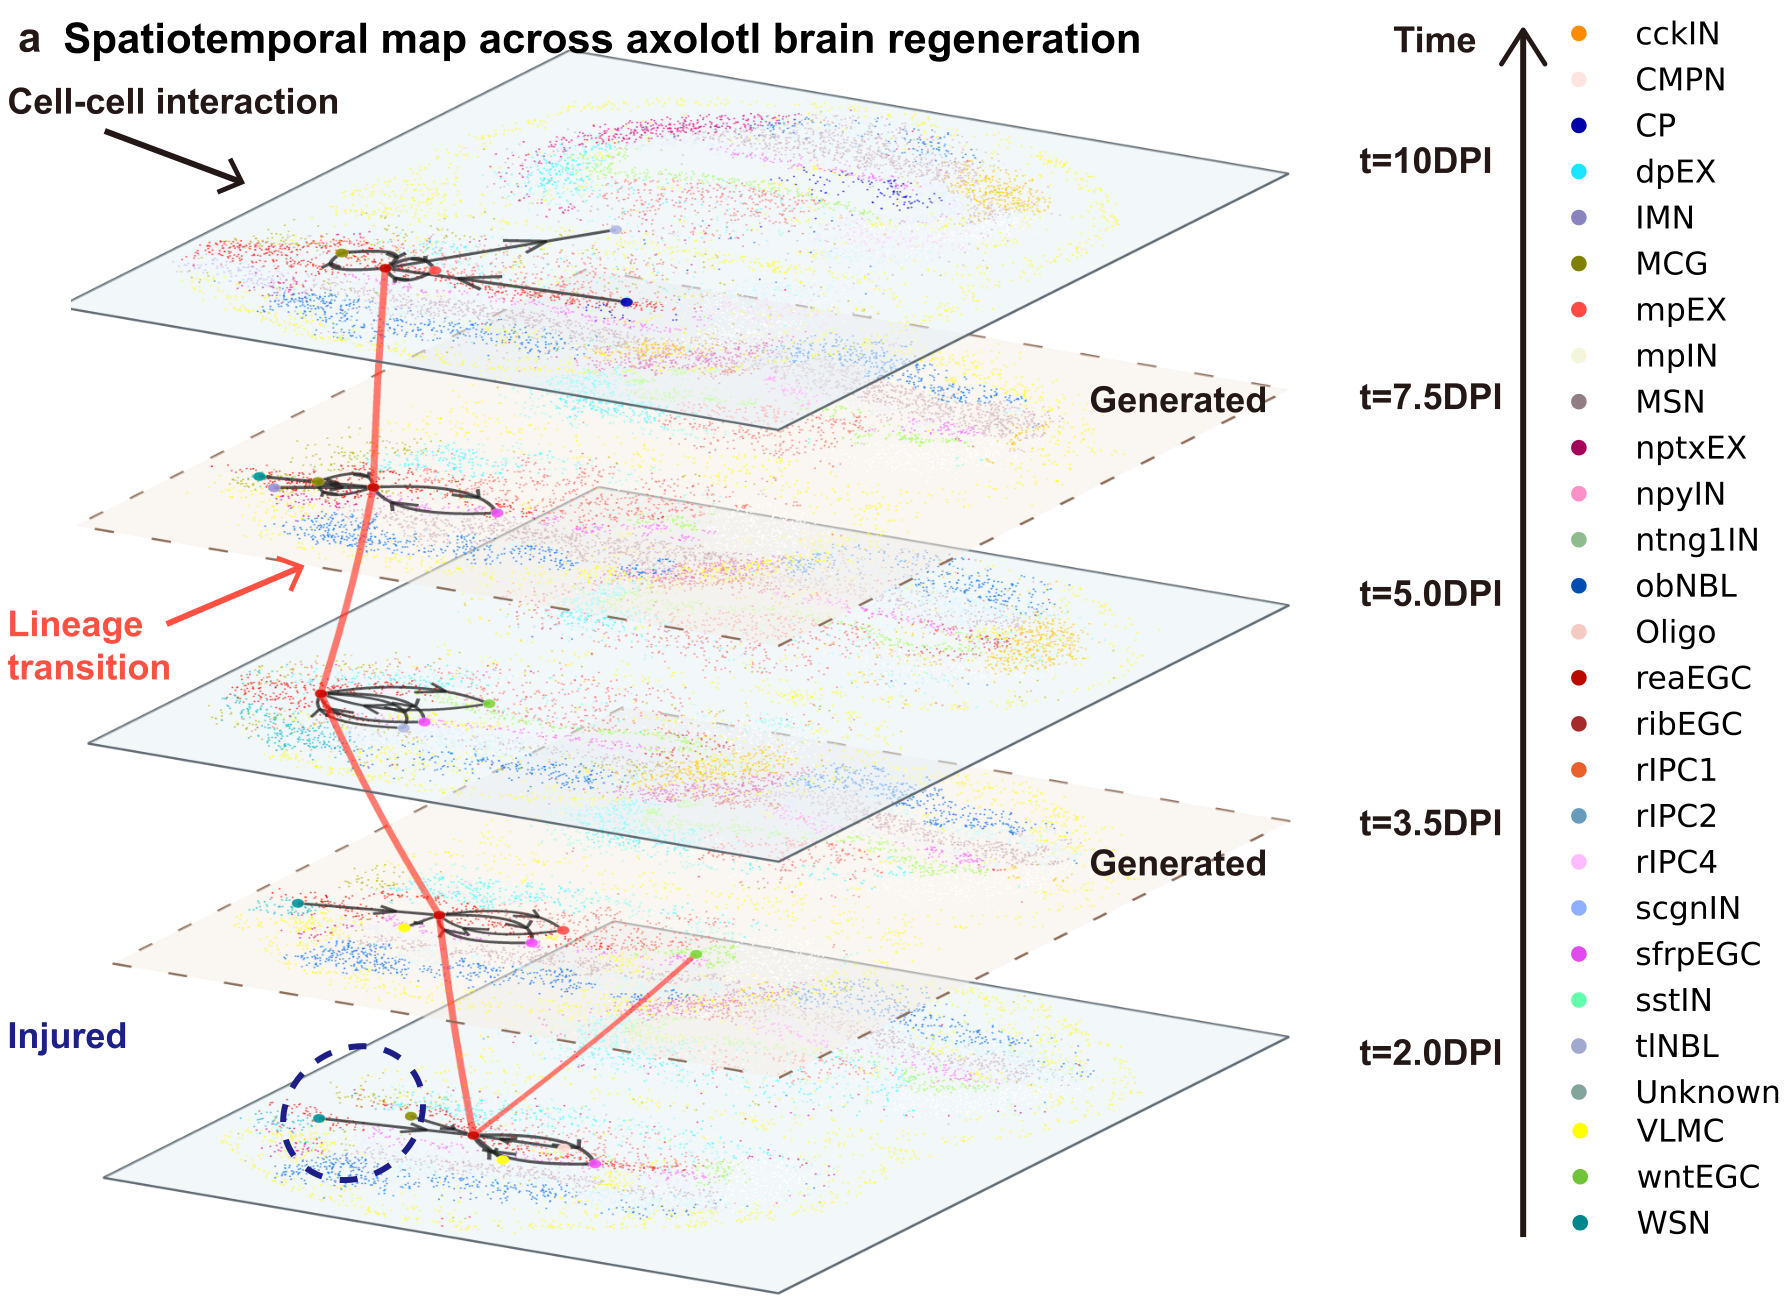

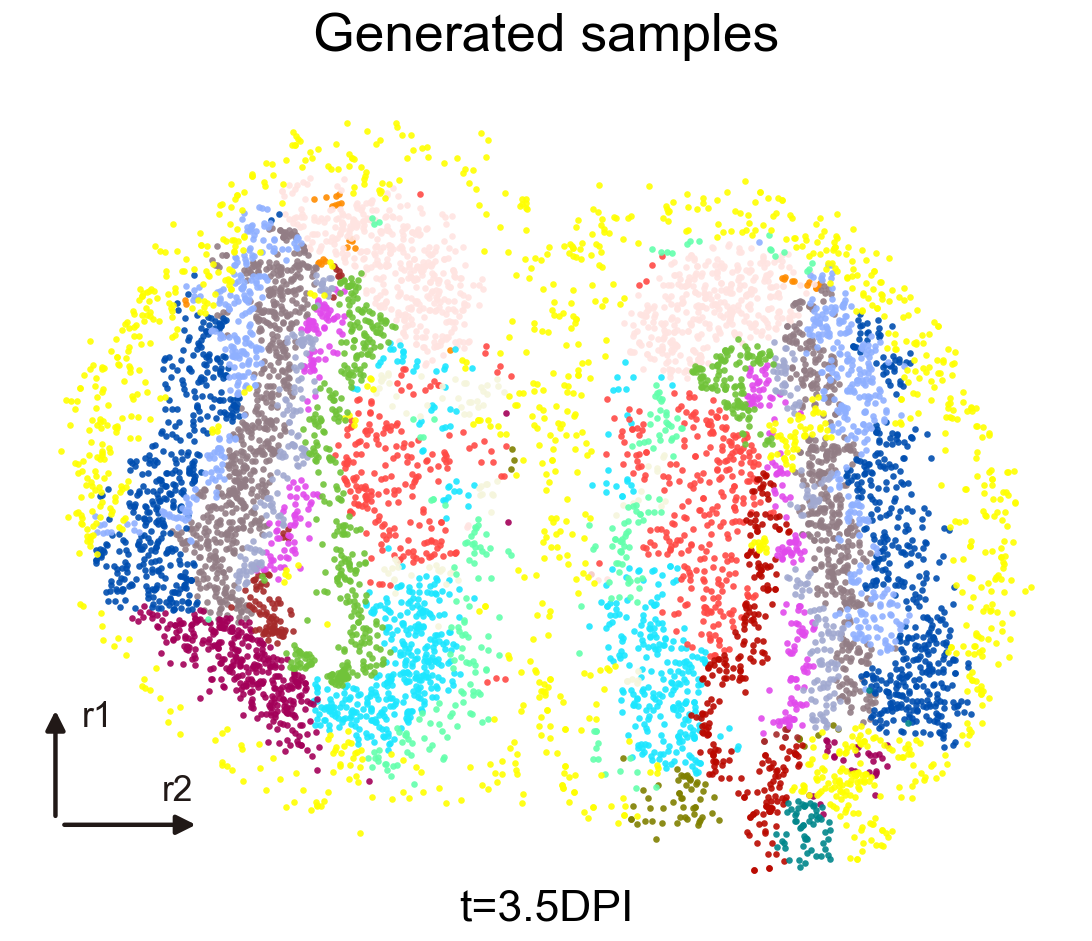

In [3]:
figures = draw_main_figure(populations, output, panels="ab")
show(figures["a"])
show(figures["b"])

## c. Evaluate and project the observed spatial field

Restore `post_simulation_rng.npz` and evaluate the five observed times in order,
using random groups of 1,024 cells for interaction. At 5 DPI, project the two
spatial components of full velocity for the left plot. Independently project
the full and interaction 52D fields onto spatial coordinates using a 30-neighbour
graph built in spatial coordinates (`X_spatial`), then calculate their cellwise
cosine for the ROI. The graph is spatial; scVelo transition directions remain 52D.

The coordinate reference supplies the cell identities, display orientation and
ROI. The calculation writes the projected vectors and cosine values to
`spatial_velocity/`; the following cells load them into the plot inputs.

In [4]:
from reproduction.arista.model_fields import calculate_observed_fields
from reproduction.arista.spatial_velocity import calculate_spatial_velocity
observed_fields = calculate_observed_fields(data, populations, analysis / "observed_fields",
                                           device=device, model_dir=model_dir)
spatial_fields = calculate_spatial_velocity(
    observed_fields / "velocity_time_1.npz", analysis / "spatial_velocity")
velocity_table = pd.read_csv(spatial_fields / "figure5c_all_cells_velocity.csv")
with np.load(spatial_fields / "figure5c_embedded_velocity.npz", allow_pickle=False) as state:
    coordinates = state["manuscript_display_coordinates"]
    spatial_vectors = state["manuscript_display_direct_embedded_velocity"]
velocity_population = ad.AnnData(X=np.zeros((len(velocity_table), 1), dtype=np.float32))
velocity_population.obs["Annotation"] = velocity_table.celltype.astype(str).to_numpy()
velocity_population.obsm["X_spatial"] = coordinates
velocity_population.obsm["velocity_spatial"] = spatial_vectors
display(velocity_table.cosine_full_vs_interaction.describe())

computing velocity graph (using 1/160 cores)


    finished (0:00:00) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding


    finished (0:00:00) --> added
    'velocity_spatial', embedded velocity vectors (adata.obsm)


computing velocity graph (using 1/160 cores)


    finished (0:00:00) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding


    finished (0:00:00) --> added
    'velocity_spatial', embedded velocity vectors (adata.obsm)


computing velocity graph (using 1/160 cores)


    finished (0:00:00) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding


    finished (0:00:00) --> added
    'velocity_spatial', embedded velocity vectors (adata.obsm)


count    8106.000000
mean       -0.125978
std         0.766982
min        -1.000000
25%        -0.886404
50%        -0.333839
75%         0.724887
max         1.000000
Name: cosine_full_vs_interaction, dtype: float64

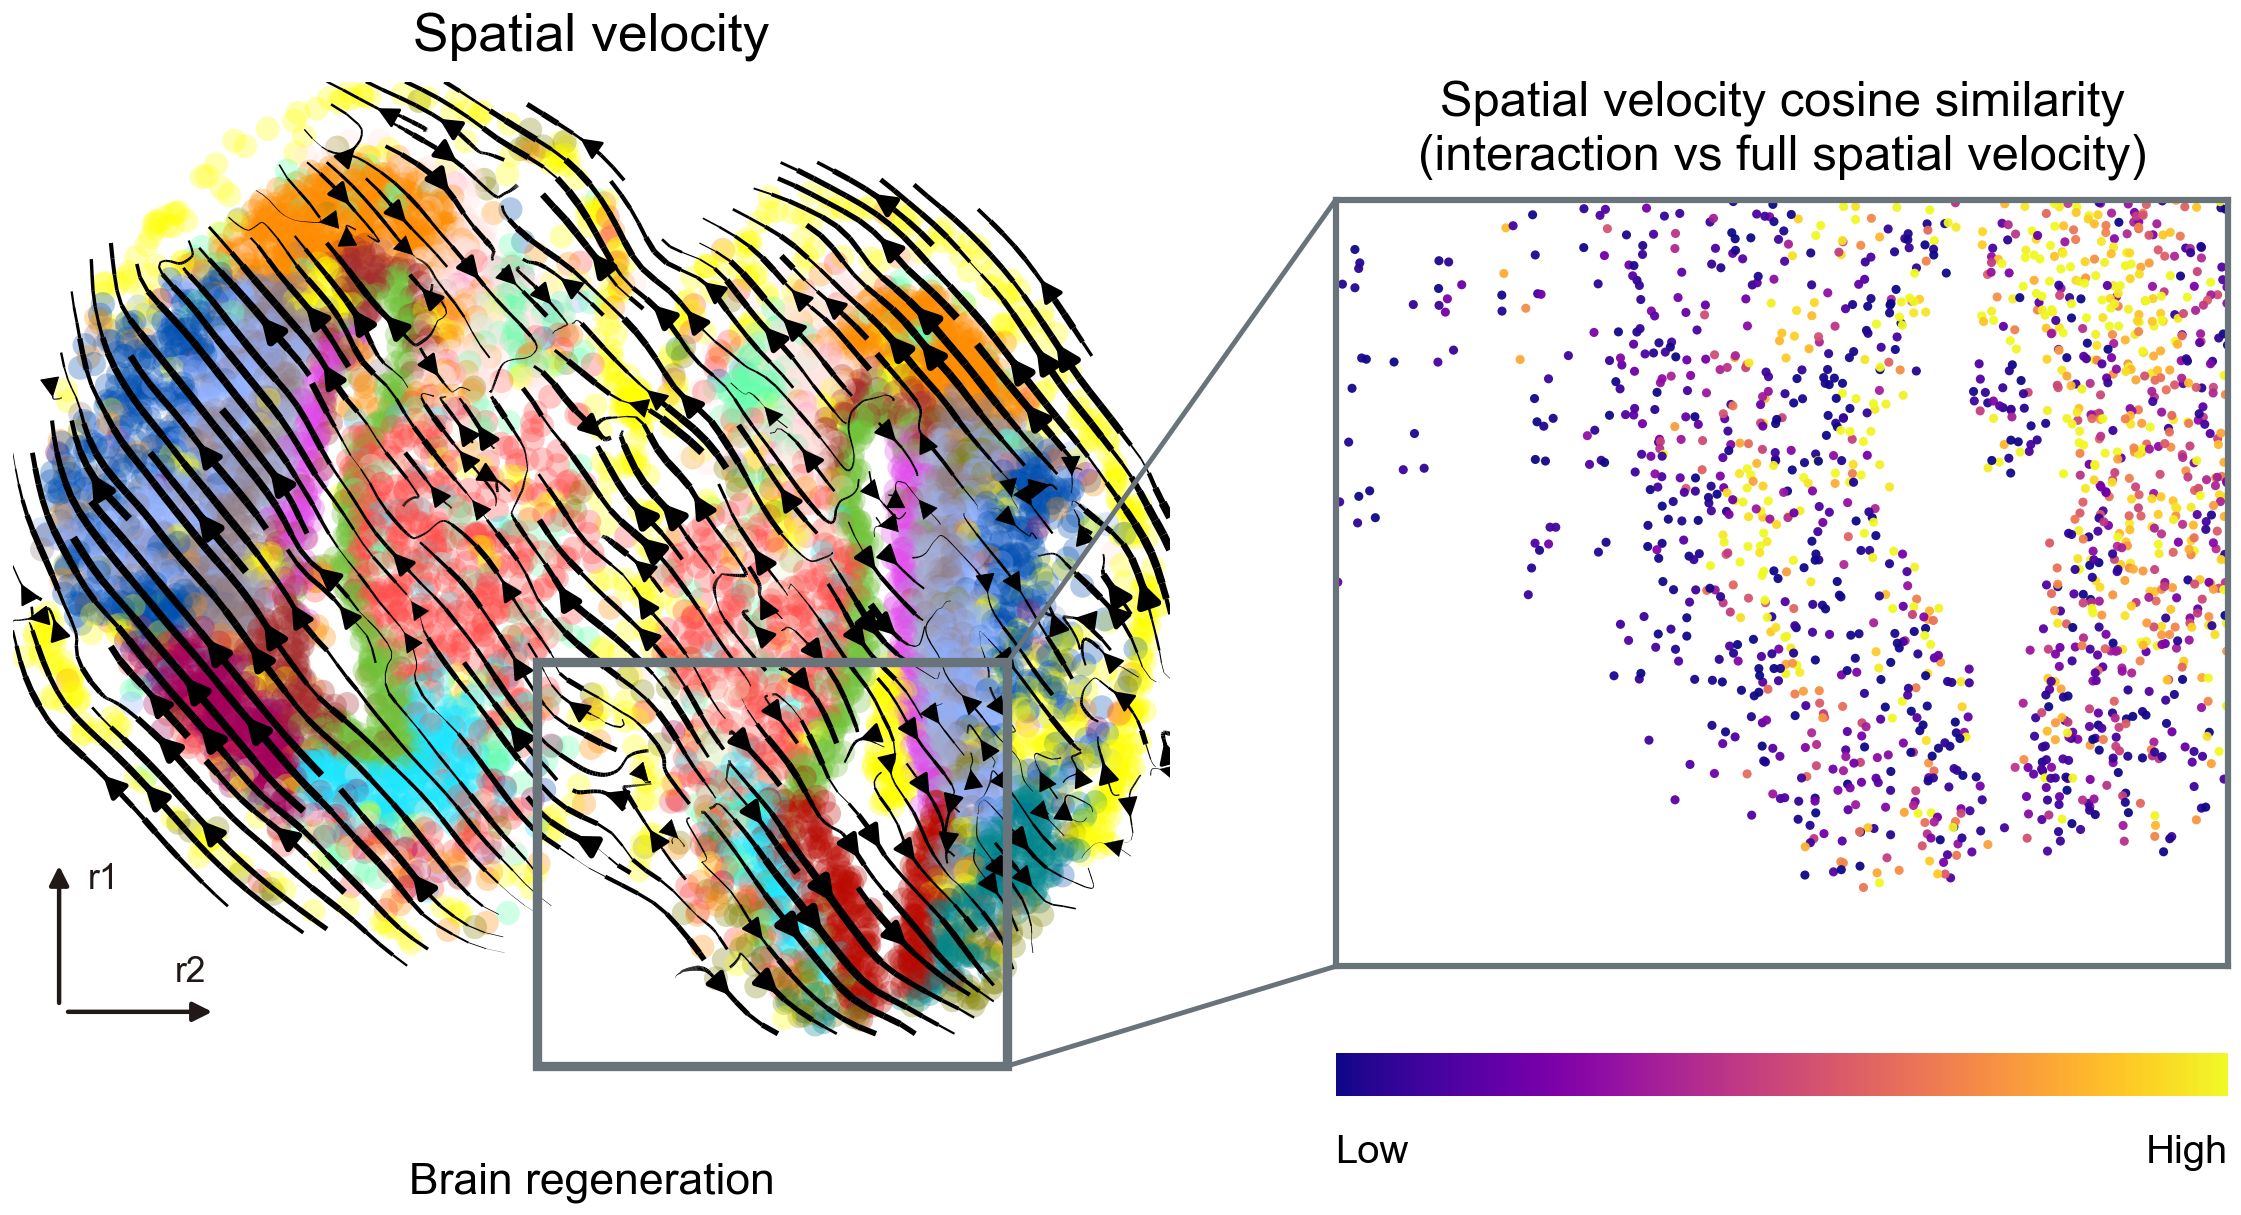

In [5]:
velocity_table.to_csv(output / "Figure5c_spatial_velocity.csv", index=False)
plotting.configure_style()
figures_c = plotting.plot_figure5c(velocity_population, velocity_table, ROI, FOCUS, palette, output)
show(figures_c["Figure5c_spatial_and_roi"])

## d. Intrinsic-context gene velocity

Evaluate intrinsic drift on all 46,199 observed cells and take the last 50
gene-state dimensions. Fit a two-component PCA, build the 30-neighbour graph
in 50D and project drift with scVelo. The calculation returns the NPZ path
read by `draw_gene_velocity`.

computing velocity graph (using 1/160 cores)


    finished (0:00:16) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding


    finished (0:00:07) --> added
    'velocity_pca', embedded velocity vectors (adata.obsm)


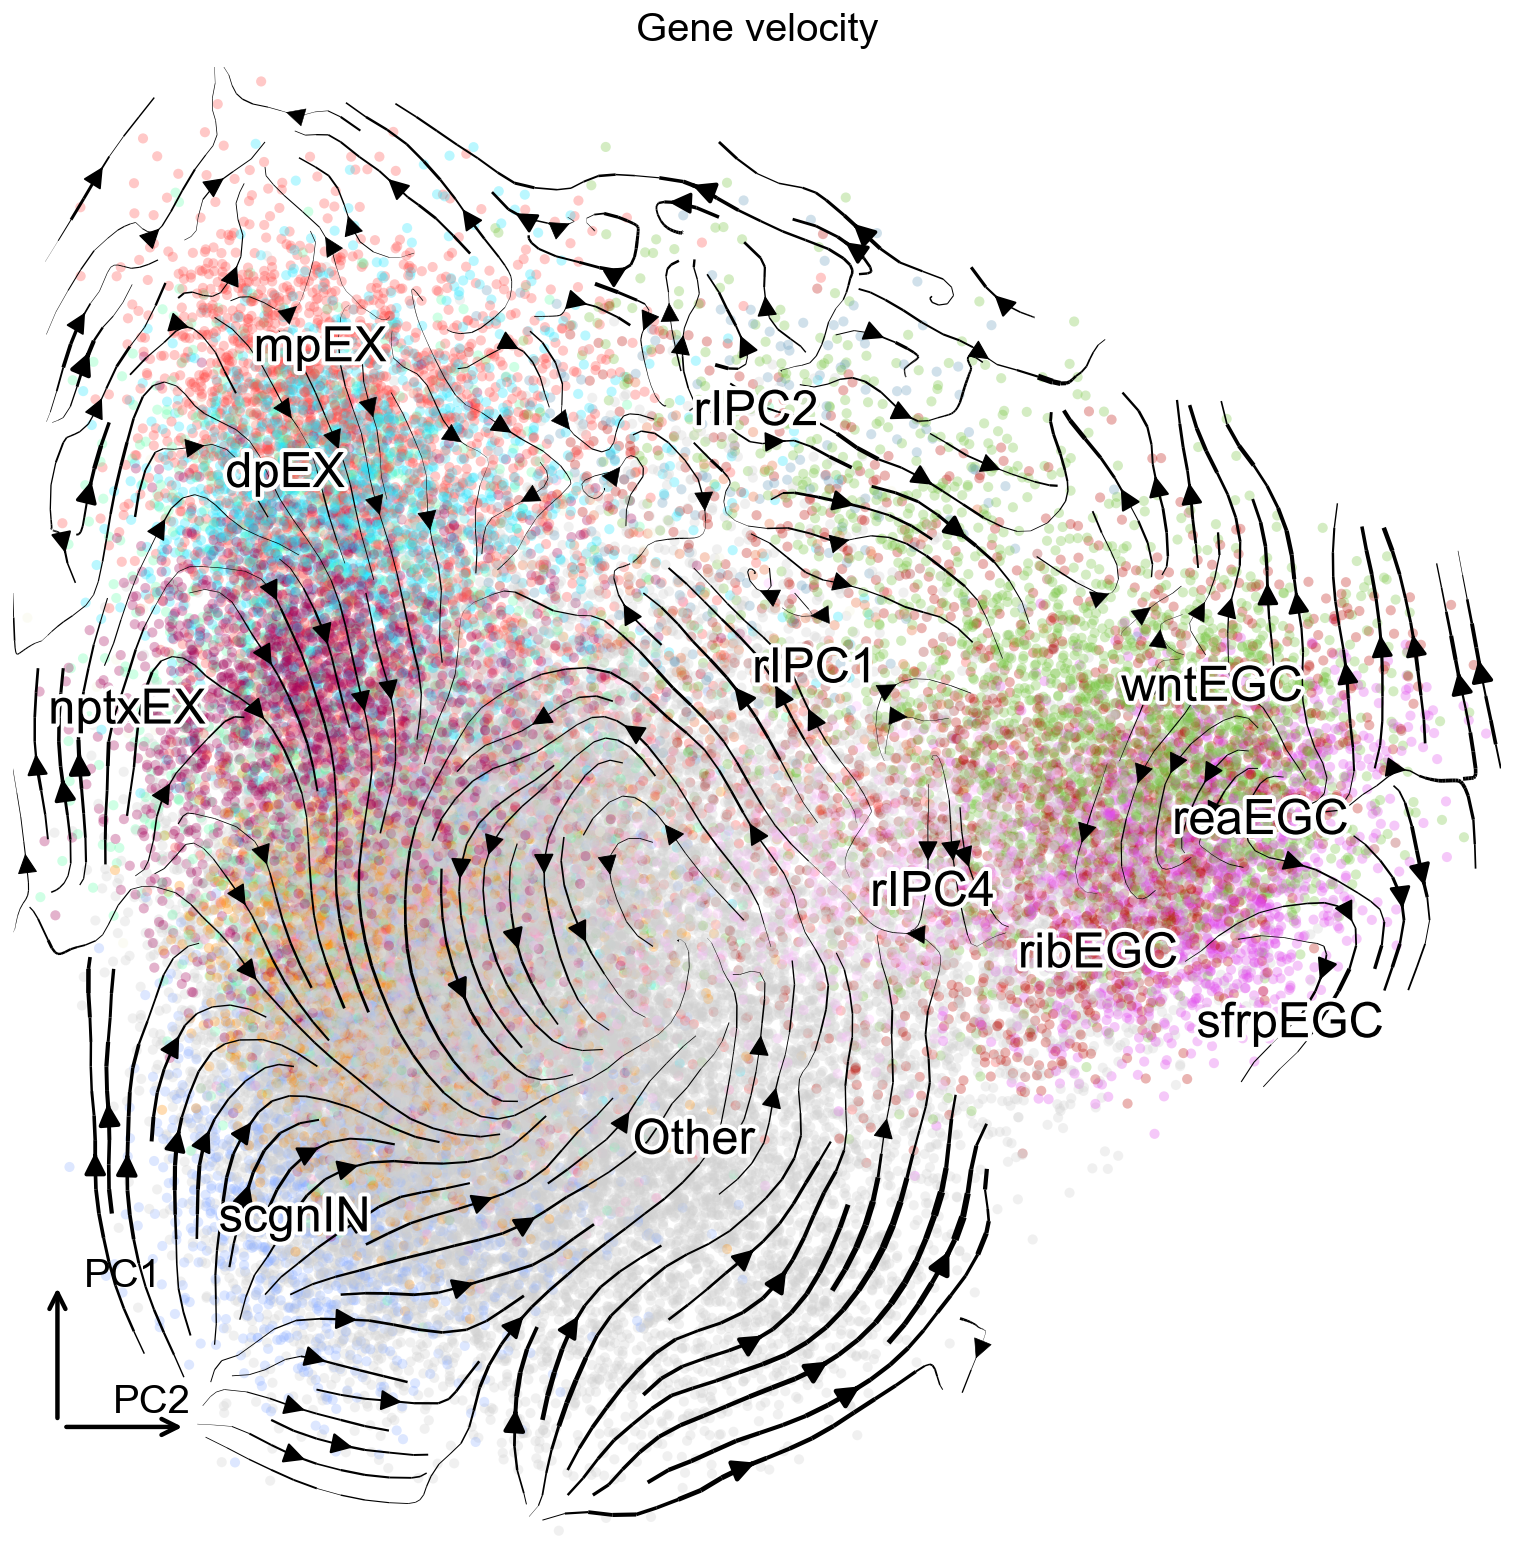

In [6]:
from reproduction.arista.gene_velocity import calculate_gene_velocity
gene_state = calculate_gene_velocity(data, analysis / "gene_velocity", device=device, model_dir=model_dir)
show(draw_gene_velocity(output, palette, state_path=gene_state))

## e. Growth and interaction

Evaluate growth and the 52D interaction-vector norm on the nine measured/
intermediate populations, then group the values by time and cell type.
This evaluation uses seed 42 and writes `fields/figure5e_growth_interaction_by_cell.csv`
and `fields/figure5e_growth_interaction_by_celltype.csv`.

In [7]:
from reproduction.arista.model_fields import calculate_fields
means = calculate_fields(model_dir, populations / "model_states",
                         analysis / "fields", device=device, seed=42)
means["time_idx"] = means.time.map({t: i for i, t in enumerate(sorted(means.time.unique()))})
display(means.head())

,time,celltype,growth_mean,interaction_mean,n,time_idx
0,0.0,CMPN,0.089906,0.242359,669,0
1,0.0,MCG,0.048441,0.272470,121,0
2,0.0,MSN,-0.010620,0.231915,797,0
3,0.0,Oligo,0.051793,0.436802,92,0
4,0.0,VLMC,0.035748,0.406315,1300,0


The paper panel below is redrawn from the original per-cell table.
Interaction evaluation uses random 1,024-cell groups, so new evaluations can
give different interaction values.

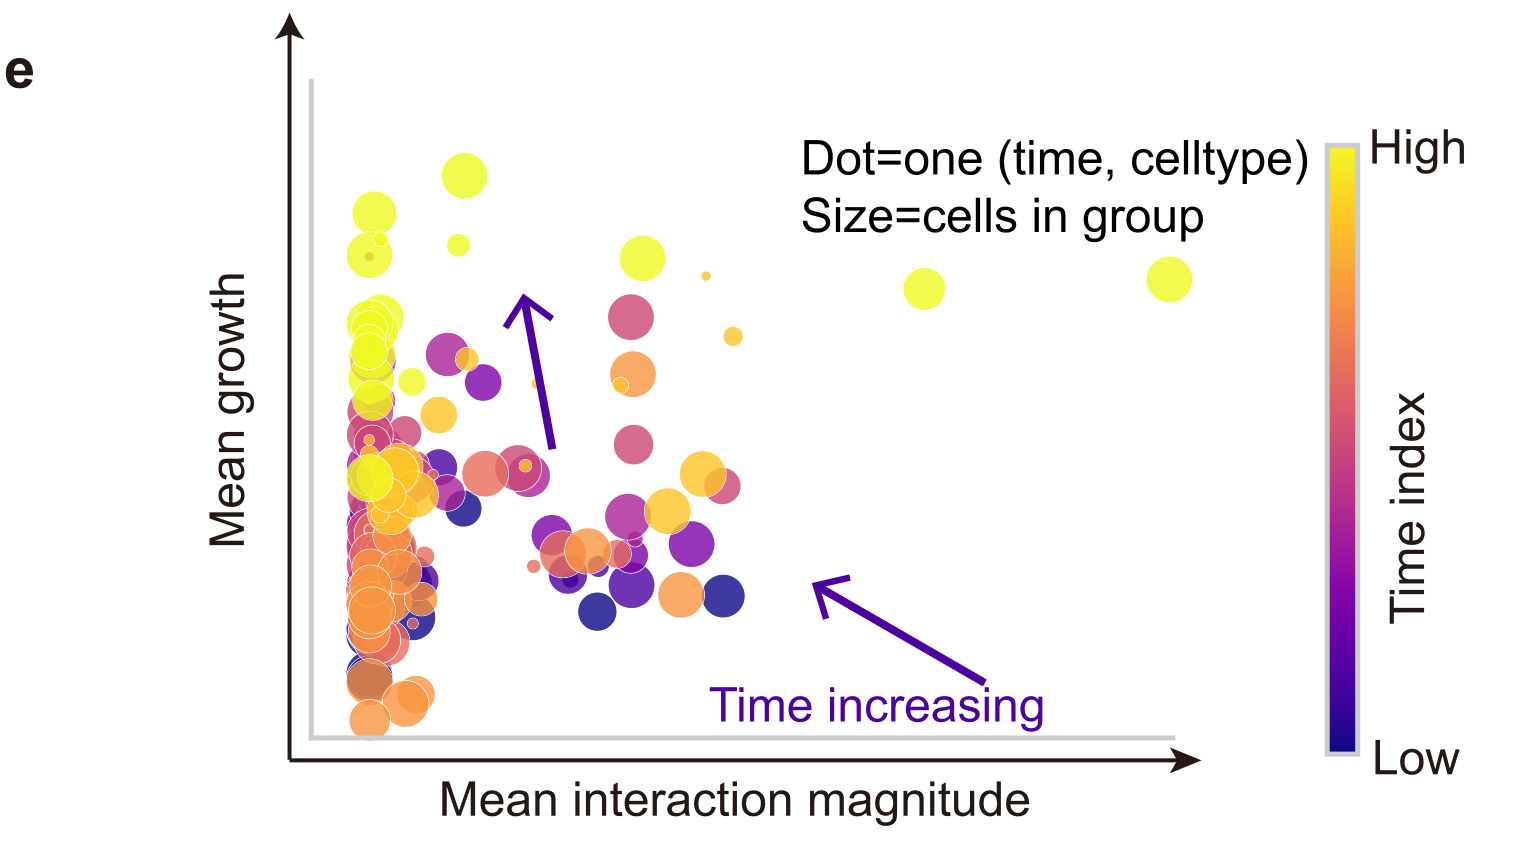

In [8]:
paper_values = pd.read_csv(SOURCE / "figure5e_growth_interaction_by_cell.csv")
paper_means = paper_values.groupby(["time", "celltype"], as_index=False).agg(
    growth_mean=("growth", "mean"), interaction_mean=("interaction", "mean"),
    n=("growth", "size"))
paper_means.to_csv(output / "Figure5e_paper_group_means.csv", index=False)
show(plot_growth_interaction(paper_means, output / "Figure5e_growth_interaction"))

[S25](arista_local_domains.ipynb) continues from the cosine values in
`spatial_velocity/figure5c_all_cells_velocity.csv`, the population attention
files and the LR time courses calculated in [S23](arista_figures.ipynb).
To repeat calculations, select a new analysis directory and begin with the
dataset notebook.
The [model-fields reference](arista_model_fields.md) also lists the individual calls.

To plot the model-derived `means` object, use the same plotting function:

```python
new_figures = analysis / "figures/new_field_evaluation"
new_figures.mkdir(parents=True, exist_ok=True)
plot_growth_interaction(means, new_figures / "seed42_growth_interaction")
```